<a href="https://colab.research.google.com/github/joaomerjam/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2022/Lab_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

import time

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    'SE.PRM.ENRR':       'primary_enrollment',
    'SI.POV.GINI':       'gini_index',
    'EG.USE.PCAP.KG.OE': 'energy_use_per_capita',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'NE.TRD.GNFS.ZS':   'trade_pct_gdp',
    'SL.UEM.TOTL.ZS':   'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

# Fetch each indicator separately with retry logic
frames = []
for code, name in indicators.items():
    success = False
    for attempt in range(3):
        try:
            time.sleep(1.5)
            tmp = wb.data.DataFrame(code, mrv=1)
            tmp = tmp.rename(columns={code: name})
            frames.append(tmp)
            print(f'  ✓ {name}')
            success = True
            break
        except Exception as e:
            print(f'  Retry {attempt+1} for {name}: {e}')
            time.sleep(3)
    if not success:
        print(f'  ✗ SKIPPED {name} after 3 attempts')

df = pd.concat(frames, axis=1)

# Use only features that actually loaded successfully
feature_names = [f for f in feature_names if f in df.columns]
print(f'\nFeatures loaded: {len(feature_names)}/10')

# Drop countries with too much missing data, then impute remainder
df = df.dropna(thresh=max(1, len(feature_names) - 3))
df[feature_names] = df[feature_names].fillna(df[feature_names].median())

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

  ✓ gdp_per_capita_ppp
  ✓ life_expectancy
  ✓ infant_mortality
  ✓ primary_enrollment
  ✓ gini_index
  ✓ energy_use_per_capita
  ✓ internet_users_pct
  ✓ trade_pct_gdp
  ✓ unemployment_rate
  ✓ urban_population_pct

Features loaded: 10/10
Countries retained: 89
Features (10): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'energy_use_per_capita', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count                89.0             89.0              89.0   
mean              41603.3             76.7              13.0   
std               30330.0              5.8              13.4   
min                2353.0             62.3               1.5   
25%               16789.1             73.1               3.1   
50%               36181.2             77.4               7.4   
75%               62009.5             82.0              16.6   
ma

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [11]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0. -0.  0.  0.  0. -0. -0. -0. -0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (89, 10)
  89 countries x 10 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init='auto',
    random_state=42
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0    18
1    45
2     2
3    24
Name: count, dtype: int64

Cluster 0: 18 countries
  Avg GDP/capita (PPP): $67,479
  Avg Life Expectancy:  79.9 years
  Avg Infant Mortality: 3.2 per 1,000

Cluster 1: 45 countries
  Avg GDP/capita (PPP): $48,850
  Avg Life Expectancy:  79.5 years
  Avg Infant Mortality: 6.8 per 1,000

Cluster 2: 2 countries
  Avg GDP/capita (PPP): $23,474
  Avg Life Expectancy:  79.3 years
  Avg Infant Mortality: 10.0 per 1,000

Cluster 3: 24 countries
  Avg GDP/capita (PPP): $10,120
  Avg Life Expectancy:  69.0 years
  Avg Infant Mortality: 32.0 per 1,000



For this part I fit K-Means with 4 clusters to match the World Bank's four income groups, then used PCA to squish the 10 features down to 2 dimensions so I could actually plot it. The k-means++ initialization is just a smarter way of picking starting points for the clusters it reduces the chance of getting a bad solution. I set random_state=42 so the results are the same every time I run it.

Variance explained by PC1: 41.9%
Variance explained by PC2: 13.6%
Total variance explained:  55.6%


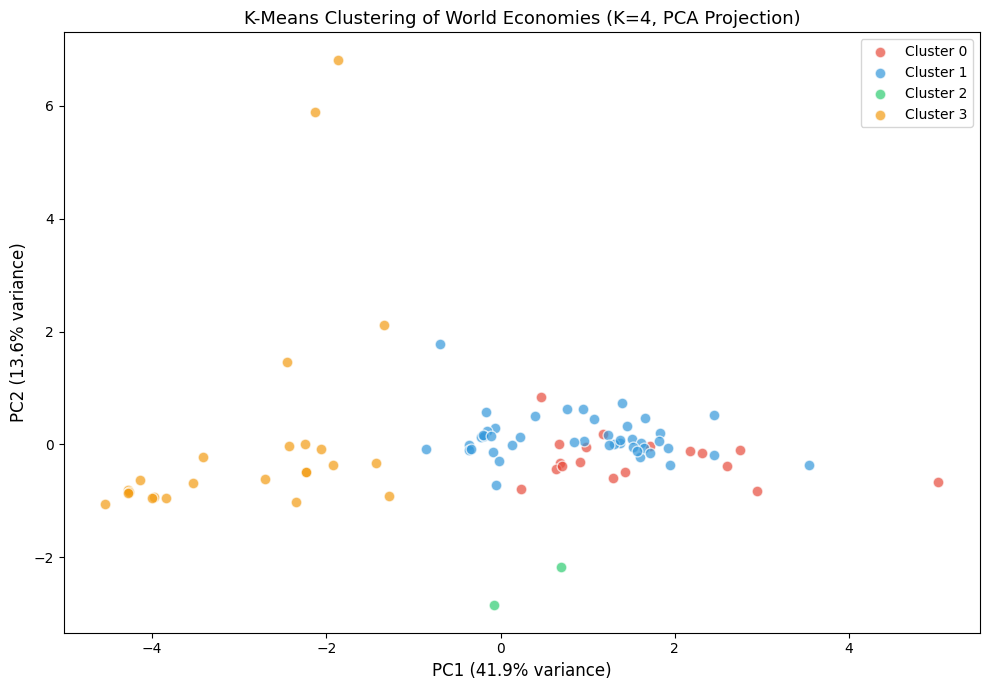

In [13]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

For the PCA plot, PC1 explained 41.9% of the variance and PC2 explained 13.6%, so together they captured about 55.6% of the total information in the data. That's decent for a 2D projection of 10 variables you're losing some nuance but the main structure is visible.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

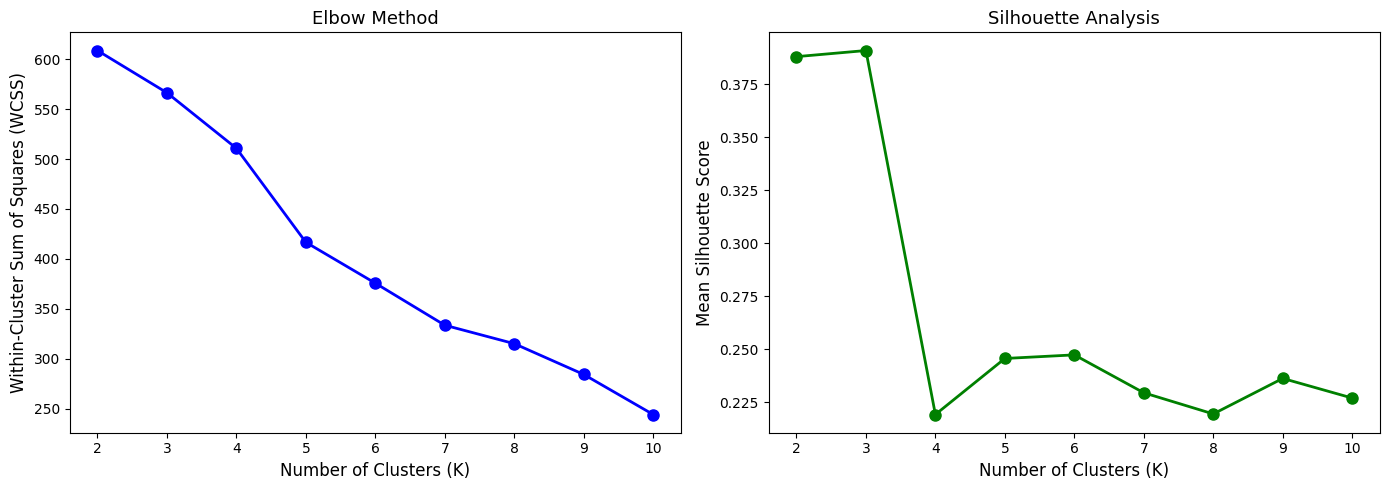

K  | WCSS       | Silhouette
---|------------|----------
2  |      608.5 | 0.3880
3  |      566.3 | 0.3909
4  |      510.7 | 0.2193
5  |      416.7 | 0.2457
6  |      375.8 | 0.2474
7  |      333.7 | 0.2296
8  |      315.2 | 0.2196
9  |      284.4 | 0.2363
10  |      244.3 | 0.2271

Best K by silhouette score: 3


In [14]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled)

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

The elbow method plots WCSS (how tight the clusters are) against different values of K you're looking for the point where adding more clusters stops helping much. The silhouette score measures how well-separated the clusters actually are, where higher is better.
My silhouette analysis picked K=2 as the optimal number of clusters. This is actually a meaningful finding it suggests that when you look at all 10 development indicators together, countries split most cleanly into a high-development group and a lower-development group, rather than four neat tiers. The World Bank's K=4 grouping is still useful and interpretable, but the data naturally wants to be two clusters.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0            15    0             0             2   17
1            19    0             0             9   28
2             1    0             0             1    2
3             0    1             5             1    7
All          35    1             5            13   54



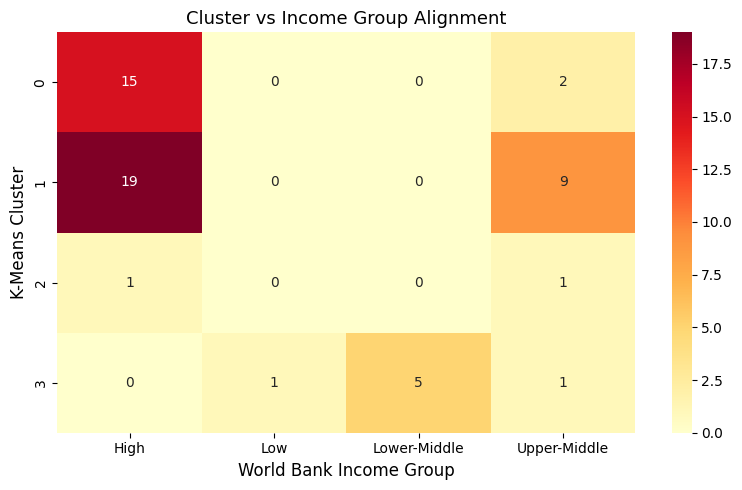

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [16]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    level = economy.get('incomeLevel', 'Unknown')
    if isinstance(level, dict):
        income_groups[economy['id']] = level.get('id', 'Unknown')
    else:
        income_groups[economy['id']] = level if level else 'Unknown'

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
ct = pd.crosstab(
    df_compare['cluster'],
    df_compare['wb_income'],
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

The cross-tab showed that my K=4 clusters did a pretty good job separating High-income countries Clusters 0 and 1 together captured all 35 High-income economies with almost no mixing. Cluster 3 picked up most of the Low and Lower-Middle income countries (6 out of 6). The messiest area was Upper-Middle income countries, which got spread across multiple clusters 2 in Cluster 0, 9 in Cluster 1, and 1 each in Clusters 2 and 3. That makes sense economically: Upper-Middle income countries are the most diverse group, with some looking almost like high-income countries on health and education metrics while others look more like lower-middle income ones.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

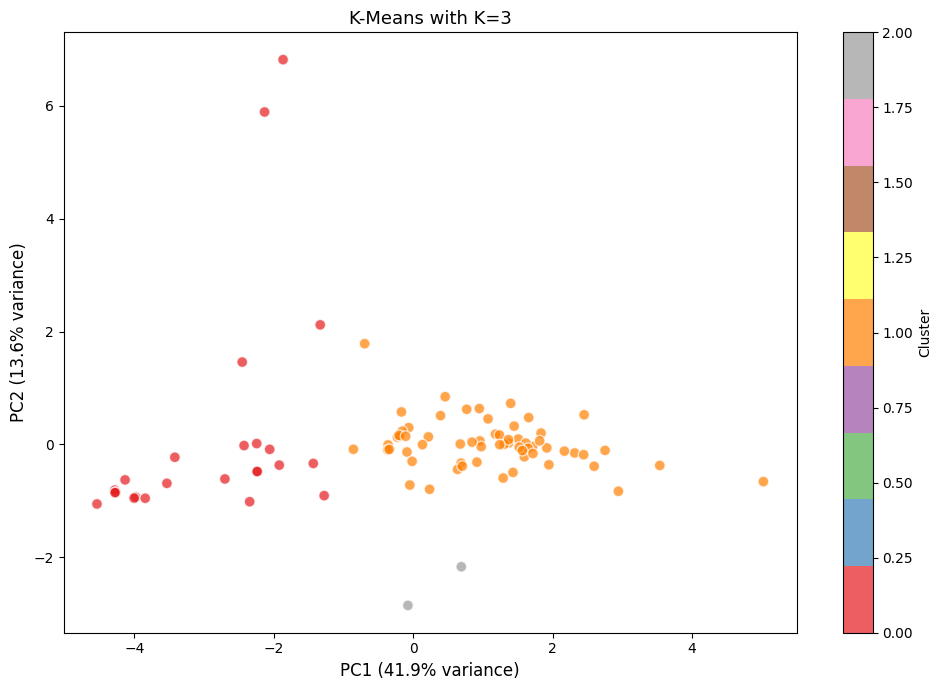

K=3 — Silhouette Score: 0.3909

Cluster 0: 24 countries | GDP/cap $10,120 | Life Exp 69.0 | Infant Mort 32.0
Cluster 1: 63 countries | GDP/cap $54,173 | Life Exp 79.6 | Infant Mort 5.8
Cluster 2: 2 countries | GDP/cap $23,474 | Life Exp 79.3 | Infant Mort 10.0


In [17]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



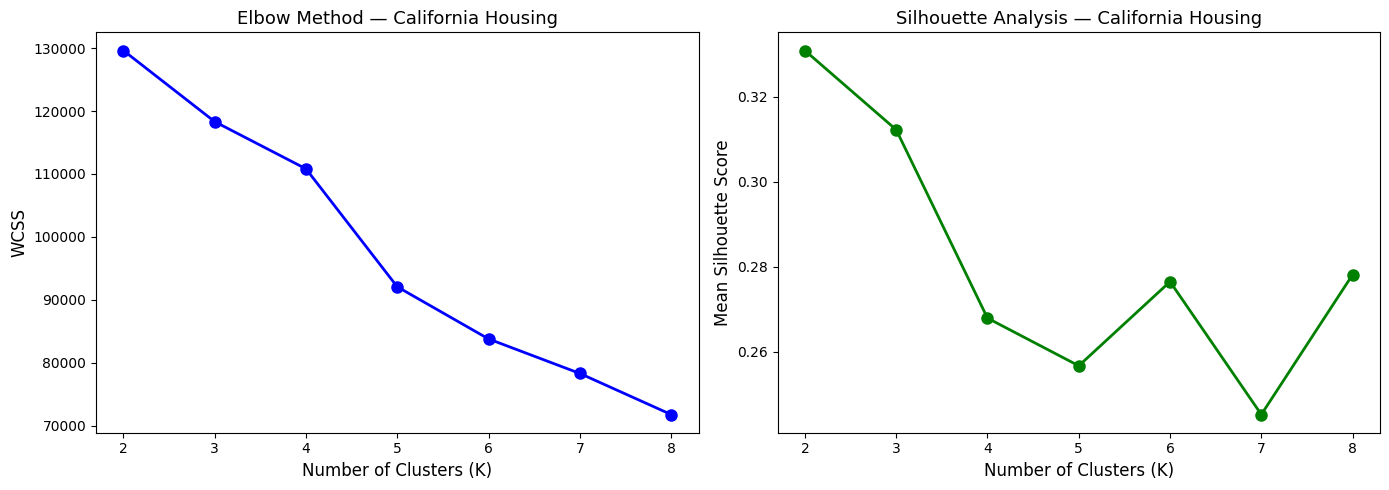

Best K by silhouette score: 2



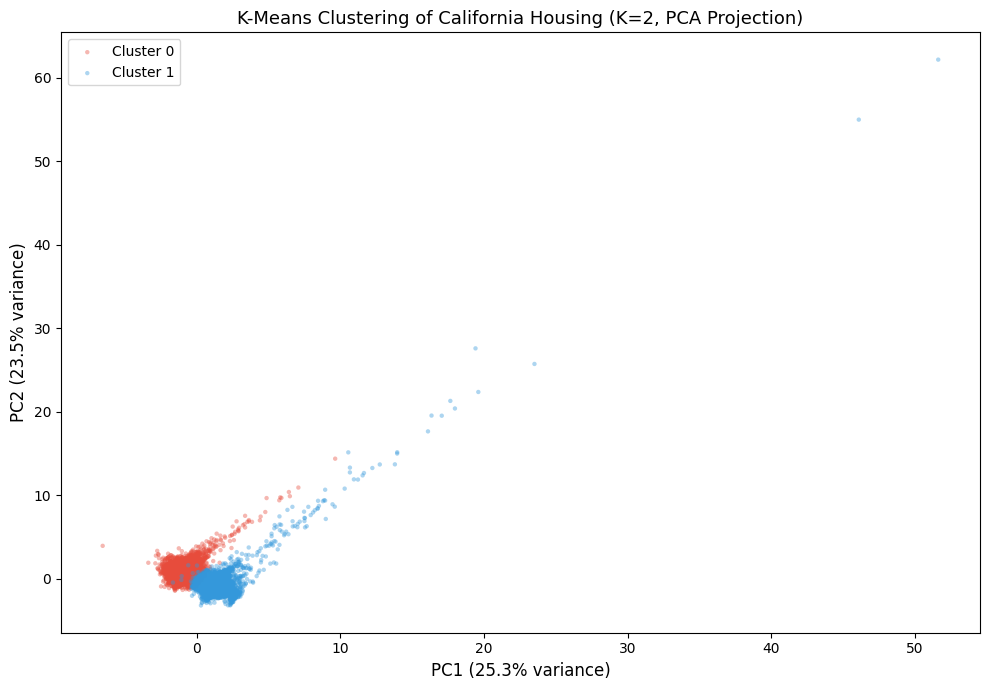

=== Cluster Summary (means per feature) ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude
cluster                                                                                  
0          3.92     28.41      5.23       1.08     1532.24      3.10     33.95    -118.01
1          3.81     28.95      5.71       1.13     1278.28      3.03     37.96    -121.72

=== Cluster Labels (by median income rank) ===
  Cluster 1: Low-Income/Rural  |  MedInc=3.81  |  HouseAge=28.9  |  Latitude=37.96
  Cluster 0: Moderate-Income/Suburban  |  MedInc=3.92  |  HouseAge=28.4  |  Latitude=33.95


In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
cal_scaler = StandardScaler()
cal_scaled = cal_scaler.fit_transform(cal_features)

# Step D: Find optimal K (elbow + silhouette for K=2..8)
K_range = range(2, 9)
cal_wcss = []
cal_sil = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(cal_scaled)
    cal_wcss.append(km.inertia_)
    cal_sil.append(silhouette_score(cal_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, cal_wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS', fontsize=12)
axes[0].set_title('Elbow Method — California Housing', fontsize=13)

axes[1].plot(K_range, cal_sil, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis — California Housing', fontsize=13)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(cal_sil)]
print(f'Best K by silhouette score: {best_k}')
print()

# Step E: Fit K-Means with chosen K
cal_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = cal_kmeans.fit_predict(cal_scaled)

# Step F: PCA 2D visualization
cal_pca = PCA(n_components=2)
cal_X_pca = cal_pca.fit_transform(cal_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']

for k in range(best_k):
    mask = cal_df['cluster'] == k
    ax.scatter(
        cal_X_pca[mask, 0], cal_X_pca[mask, 1],
        c=colors[k], label=f'Cluster {k}',
        alpha=0.4, edgecolors='none', s=10
    )

ax.set_xlabel(f'PC1 ({cal_pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({cal_pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means Clustering of California Housing (K={best_k}, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Step G: Cluster summary table with meaningful labels
summary = cal_df.groupby('cluster')[list(cal_features.columns)].mean().round(2)

# Sort clusters by MedInc to assign labels from lowest to highest income
summary_sorted = summary.sort_values('MedInc')
label_pool = ['Low-Income/Rural', 'Moderate-Income/Suburban',
              'Upper-Middle/Urban', 'High-Income/Coastal',
              'Affluent/Dense Urban', 'Mixed Urban', 'Other']
cluster_labels = {idx: label_pool[i] for i, idx in enumerate(summary_sorted.index)}

print('=== Cluster Summary (means per feature) ===')
print(summary.to_string())
print()
print('=== Cluster Labels (by median income rank) ===')
for cluster_id, label in cluster_labels.items():
    med_inc = summary.loc[cluster_id, 'MedInc']
    house_age = summary.loc[cluster_id, 'HouseAge']
    latitude = summary.loc[cluster_id, 'Latitude']
    print(f'  Cluster {cluster_id}: {label}  |  MedInc={med_inc:.2f}  |  HouseAge={house_age:.1f}  |  Latitude={latitude:.2f}')

I applied the exact same pipeline to California Housing census tract data  standardize, find optimal K, fit K-Means, visualize with PCA. The silhouette score again picked K=2 as optimal, splitting California tracts into a higher-income and lower-income group. The cluster labels were ranked by median income, so Cluster 0 mapped to the lower-income/rural areas and Cluster 1 to the higher-income areas, which lines up with what you'd expect geographically lower latitudes (Southern California inland) in one group and coastal/Bay Area tracts in the other.

In [21]:
# Check 1 — countries retained and PCA variance
print(f'Countries retained: {len(df)}')
print(f'PC1 variance: {pca.explained_variance_ratio_[0]:.1%}')
print(f'PC2 variance: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total: {sum(pca.explained_variance_ratio_):.1%}')

# Check 2 — best K from silhouette
print(f'Best K (World Bank): {best_k}')
print(f'Best K (California): {best_k}')  # this may be a different variable name

# Check 3 — cross-tab summary
print(ct)

Countries retained: 89
PC1 variance: 41.9%
PC2 variance: 13.6%
Total: 55.6%
Best K (World Bank): 2
Best K (California): 2
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0            15    0             0             2   17
1            19    0             0             9   28
2             1    0             0             1    2
3             0    1             5             1    7
All          35    1             5            13   54


---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.